# Zero-kernel coupling  ≡  diagonal Gaussianization

A coupling flow with mixture-CDF blocks normally captures cross-dim dependence via the conditioner. But when the conditioner is *zero-initialised* — specifically, when the **final** Dense of the conditioner has kernel $W = 0$ — something interesting happens: the flow collapses into a plain diagonal Gaussianization flow.

This notebook:

1. Recaps the four objects at play (the mixture-CDF primitive, the diagonal Gaussianization flow, iterative vs parametric training, the coupling flow).
2. Works through the math showing the equivalence (Lemmas 1–3 → Theorem → Corollary).
3. Verifies it empirically: build matched diagonal and coupling flows, IG-initialise both, compare pushforwards element-wise.
4. Shows that a single gradient step is enough for the coupling flow to *break* the equivalence — its conditioner starts modulating on $x_a$ and the flow becomes strictly more expressive.

The upshot: IG init on a coupling flow gives you the best of both worlds — a well-understood RBIG starting point *and* a conditioner waiting to do cross-dim work once training begins.

## 1. Mathematical recap

Self-contained summary of the pieces so this notebook stands on its own.

### Notation and shapes

- $d$ — data dimensionality, $K$ — mixture components per marginal, $N$ — batch size, $L$ — number of blocks in the flow.
- Random vector $X \sim p_X$ on $\mathbb{R}^d$ (what we have data from). Latent $Z \sim p_Z = \mathcal{N}(0, I_d)$ (what we want the flow to land on).
- Bijective map $f: \mathbb{R}^d \to \mathbb{R}^d$ with Jacobian $J_f(x) \in \mathbb{R}^{d \times d}$.

### Change of variables (the one identity behind everything)

For a bijection $z = f(x)$ and any base density $p_Z$,
$$\log p_X(x) \;=\; \log p_Z\!\big(f(x)\big) \;+\; \log\lvert\det J_f(x)\rvert.$$
Training minimises the negative of this averaged over data — the NLL.

### 1-D mixture-CDF Gaussianization (the primitive)

Classical probability integral transform: if $X$ has strictly increasing CDF $F$, then $F(X) \sim \text{Uniform}[0, 1]$, so $\Phi^{-1}(F(X)) \sim \mathcal{N}(0, 1)$. We approximate $F$ with a mixture of $K$ normals,
$$F(x;\,\pi, \mu, \sigma) \;=\; \sum_{k=1}^{K} \pi_k \,\Phi\!\big((x - \mu_k)/\sigma_k\big), \qquad f(x;\,\pi, \mu, \sigma) \;=\; \sum_{k=1}^{K} \pi_k\,\sigma_k^{-1}\,\varphi\!\big((x - \mu_k)/\sigma_k\big).$$
Parameter shapes: $\pi \in \Delta^{K-1}$ (weights on the simplex), $\mu \in \mathbb{R}^K$, $\sigma \in \mathbb{R}_{>0}^K$. The forward map and its log-derivative are
$$z \;=\; \Phi^{-1}\!\big(F(x)\big), \qquad \log\lvert \partial z / \partial x \rvert \;=\; \log f(x) - \log \varphi(z).$$
Inverse uses monotone bisection on $F(x) = \Phi(z)$.

### Diagonal marginal Gaussianization layer (`MixtureCDFGaussianization`)

Lift the 1-D primitive to $d$ dims by applying it *independently* per dim. Parameters are tensors of shape $(d, K)$:
$$\pi \in \mathbb{R}^{d \times K}, \qquad \mu \in \mathbb{R}^{d \times K}, \qquad \log\sigma \in \mathbb{R}^{d \times K}.$$
Forward: $z_i = \Phi^{-1}\!\big(F(x_i;\, \pi_i, \mu_i, \sigma_i)\big)$ for each $i = 1, \dots, d$. Jacobian is **diagonal**, so
$$\log\lvert\det J_{\text{diag}}(x)\rvert \;=\; \sum_{i=1}^{d} \big[\log f(x_i;\, \pi_i, \mu_i, \sigma_i) \,-\, \log\varphi(z_i)\big].$$

### Rotation layer

Orthogonal $Q \in O(d)$ — either a Householder product $Q = H_{K-1}\cdots H_0$ with $H_j = I - 2\,v_j v_j^\top / \lVert v_j \rVert^2$, or a fixed (frozen) matrix. $\lvert\det Q\rvert = 1$, so rotations contribute **zero** to the flow's log-det. Their role is to redistribute non-Gaussianity across dims between marginal blocks — a marginal layer can only Gaussianize dim-by-dim, so the rotation "mixes" structure that's otherwise stuck in single dims.

### A full Gaussianization flow: $L$ blocks of (rotation, marginal)

$$f(x) \;=\; \big(\text{marg}_L \circ Q_L\big) \circ \cdots \circ \big(\text{marg}_1 \circ Q_1\big)(x)$$
with total log-det $\sum_{\ell} \log\lvert\det J_{\text{marg}_\ell}\rvert$ (rotations drop out).

### Iterative Gaussianization — **RBIG** (Laparra & Malo 2011)

Greedy, **non-gradient** fit. Walk through the flow one block at a time. Starting with $Y^{(0)} = X$:
1. Fit $Q_\ell = $ PCA$(Y^{(\ell-1)})$, rotate: $Y'_\ell = Y^{(\ell-1)} Q_\ell$.
2. Fit per-dim GMM via EM on each column of $Y'_\ell$ → $(\pi_\ell, \mu_\ell, \sigma_\ell)$ of shape $(d, K)$.
3. Apply the marginal transform: $Y^{(\ell)} = $ `marg`$(Y'_\ell;\, \pi_\ell, \mu_\ell, \sigma_\ell)$.
4. Increment $\ell$ and repeat.

Laparra & Malo show the **negentropy** $J(Y^{(\ell)}) = D_\text{KL}\!\big(Y^{(\ell)} \,\Vert\, \mathcal{N}(0, I)\big)$ decreases at a *geometric* rate under mild conditions. Remarkably, this already gives a decent density estimator — *before* any gradient descent.

### Parametric Gaussianization

**Same architecture** as above. All parameters $\{(\pi_\ell, \mu_\ell, \sigma_\ell, Q_\ell)\}_{\ell=1}^{L}$ are learned **jointly** by gradient descent on the NLL. Gradient flows through the *whole* composition, so later blocks can compensate for finite-$K$ approximation errors in earlier blocks — something RBIG fundamentally cannot do.

### Coupling flow (the `MixtureCDFCoupling` layer)

Swap the diagonal marginal for a **conditional** transform. Pick a mask $m \in \{0, 1\}^d$. It splits $x$ into an "identity" half $x_a$ (indices where $m_i = 1$, size $d_a$) and a "transformed" half $x_b$ (indices where $m_i = 0$, size $d_b = d - d_a$).

A **conditioner** $\theta: \mathbb{R}^{d_a} \to \mathbb{R}^{3 \cdot d_b \cdot K}$ maps $x_a$ to the mixture parameters that will Gaussianize $x_b$. Decompose it through its final Dense as
$$\theta(x_a) \;=\; W\,\phi(x_a) + c,$$
where $\phi(x_a) \in \mathbb{R}^{h}$ is the output of the MLP body, $W \in \mathbb{R}^{h \times 3 d_b K}$, $c \in \mathbb{R}^{3 d_b K}$. The output is reshaped to $(3, d_b, K)$ and split into $(\pi_i(x_a), \mu_i(x_a), \log\sigma_i(x_a))_{i \in b}$ — one mixture per $b$-dim, *depending on* $x_a$.

The forward map:
$$z_a \;=\; x_a, \qquad z_{b,i} \;=\; \Phi^{-1}\!\big(F(x_{b,i};\, \pi_i(x_a), \mu_i(x_a), \sigma_i(x_a))\big) \;\; \text{for } i \in b.$$

Jacobian is **block-triangular** (top half is the identity on $x_a$, bottom-left carries $\partial z_b / \partial x_a$, bottom-right is diagonal). Only the bottom-right diagonal enters the determinant:
$$\log\lvert\det J_\text{coupling}(x)\rvert \;=\; \sum_{i \in b} \log\lvert \partial z_{b,i} / \partial x_{b,i} \rvert \;=\; \sum_{i \in b} \big[\log f(x_{b,i};\, \theta_i(x_a)) - \log\varphi(z_{b,i})\big].$$
Same *form* as the diagonal marginal's log-det — only difference is that the mixture params are functions of $x_a$ instead of fixed.

`make_coupling_flow` stacks blocks of $[\text{rotation},\, \text{couple}(m),\, \text{couple}(\neg m)]$: the mask swap ensures that both halves get transformed within each block.

### The equivalence we're going to prove

A diagonal Gaussianization flow is strictly less expressive than a coupling flow — the coupling has the freedom to modulate its mixture on $x_a$ (through $\theta$); the diagonal cannot. **But** when the conditioner's final Dense has $W = 0$, the function collapses: $\theta(x_a) = c$ is the same for every $x_a$, and the coupling layer reduces exactly to a diagonal marginal with params unpacked from $c$. This is the regime IG init puts the coupling flow into.

## 2. The setup — coupling layer, decomposed

With the recap in hand, zoom in on a single coupling layer. Input $x \in \mathbb{R}^{N \times d}$ (batch $N$, dim $d$). Mask $m$ picks the $d_a$ "identity" dims and $d_b = d - d_a$ "transformed" dims. Write $x_a \in \mathbb{R}^{N \times d_a}$ and $x_b \in \mathbb{R}^{N \times d_b}$ for the two halves.

The conditioner final-Dense decomposition repeated here for convenience:
$$\theta(x_a) \;=\; W\,\phi(x_a) + c.$$

**IG init sets $W = 0$ and $c$ to the RBIG fit.**

### Lemma 1 — the conditioner becomes a constant

With $W = 0$,
$$\theta(x_a) \;=\; 0 \cdot \phi(x_a) + c \;=\; c \quad \text{for every } x_a.$$
Every example sees the *same* mixture parameters. The forward pass on $x_b$ is therefore
$$z_b \;=\; \Phi^{-1}\!\big(F(x_b;\,c)\big),$$
a function of $x_b$ alone.

### Lemma 2 — the log-det collapses to a diagonal

The coupling Jacobian is block-triangular:
$$J_{\text{coupling}} \;=\; \begin{pmatrix} I_{d_a} & 0 \\ \ast & \mathrm{diag}(\partial z_{b,i}/\partial x_{b,i}) \end{pmatrix}.$$
The off-diagonal block $\ast$ carries $\partial \theta(x_a)/\partial x_a$ through the chain rule, but with $W = 0$ we get $\partial \theta / \partial x_a = 0$, so $\ast = 0$ too. The matrix is now *block-diagonal*, and
$$\log\lvert\det J_\text{coupling} \rvert \;=\; \sum_{i \in b} \log\lvert \partial z_{b,i}/\partial x_{b,i} \rvert.$$
Which is exactly what a diagonal `MixtureCDFGaussianization` layer would produce on the same $b$-indices with the same mixture params.

### Lemma 3 — two complementary-mask layers pair into one full-$d$ marginal  (pedantic)

A single coupling layer only transforms the $b$-dim half. `make_coupling_flow` uses *pairs* `[couple(m), couple(~m)]` inside each block. Claim: with zero-kernel init, one such pair equals one full-$d$ diagonal marginal layer. Proof by index chase.

Let the first layer use mask $m$ with index set $a_1 = \{i : m_i = 1\}$, $b_1 = \{i : m_i = 0\}$, $d_{a_1} = \lvert a_1 \rvert$, $d_{b_1} = \lvert b_1 \rvert$. Its zero-kernel parameters pack into a bias $c^{(1)} \in \mathbb{R}^{3 d_{b_1} K}$ encoding per-b-dim params $\theta^{(1)}_i = (\pi^{(1)}_i, \mu^{(1)}_i, \sigma^{(1)}_i)$ for $i \in b_1$. Forward:
$$y_i \;=\; x_i \quad \forall i \in a_1, \qquad y_i \;=\; \Phi^{-1}(F(x_i;\,\theta^{(1)}_i)) \quad \forall i \in b_1.$$

The second layer uses $\neg m$. Its index sets are swapped: $a_2 = b_1$, $b_2 = a_1$. With its zero-kernel bias $c^{(2)}$ encoding params $\theta^{(2)}_i$ for $i \in a_1$, forward:
$$z_i \;=\; y_i \quad \forall i \in a_2 = b_1, \qquad z_i \;=\; \Phi^{-1}(F(y_i;\,\theta^{(2)}_i)) \quad \forall i \in b_2 = a_1.$$

Now substitute $y$ in terms of $x$. For $i \in b_1$ we have $z_i = y_i = \Phi^{-1}(F(x_i;\,\theta^{(1)}_i))$ (unchanged by layer 2). For $i \in a_1$ we have $y_i = x_i$ (untouched by layer 1), so $z_i = \Phi^{-1}(F(x_i;\,\theta^{(2)}_i))$. Combining:
$$z_i \;=\; \begin{cases} \Phi^{-1}(F(x_i;\,\theta^{(2)}_i)), & i \in a_1, \\ \Phi^{-1}(F(x_i;\,\theta^{(1)}_i)), & i \in b_1. \end{cases}$$
Each dimension is Gaussianized independently by its own mixture, with no cross-dim interaction — the definition of a full-$d$ diagonal marginal layer. Take its parameters to be
$$\theta_i \;=\; \begin{cases} \theta^{(2)}_i, & i \in a_1, \\ \theta^{(1)}_i, & i \in b_1, \end{cases}$$
and the coupling pair equals `MixtureCDFGaussianization` with those parameters. Log-dets add the same way:
$$\log|\det J| \;=\; \sum_{i \in a_1} \log\lvert\partial z_i / \partial y_i \rvert + \sum_{i \in b_1} \log\lvert\partial y_i/\partial x_i\rvert \;=\; \sum_{i = 1}^{d} \log\lvert\partial z_i / \partial x_i\rvert. \qquad\square$$

### Theorem — full-flow equivalence at zero-kernel init

A coupling flow
$$f_\text{cpl}  \;=\; \big[\text{rot}_L,\,\text{couple}(m),\,\text{couple}(\neg m)\big] \circ \cdots \circ \big[\text{rot}_1,\,\text{couple}(m),\,\text{couple}(\neg m)\big]$$
with zero-kernel init on every coupling layer reduces, by Lemma 3 applied block-by-block, to
$$f_\text{diag}  \;=\; \big[\text{rot}_L,\,\text{marginal}_L\big] \circ \cdots \circ \big[\text{rot}_1,\,\text{marginal}_1\big],$$
**provided the rotations and marginal parameters are matched**. `initialize_flow_from_ig` walks both kinds of flow with the same per-block PCA and per-dim GMM fits (seeded by `(block_idx, dim_idx)`), so the matching holds automatically.

### Corollary — both flows equal RBIG

Classical RBIG produces exactly the sequence of $(\text{rotation}, \text{marginal})$ transforms that `initialize_flow_from_ig` assigns, so
$$f^{\,\text{IG-init}}_\text{cpl}(x) \;=\; f^{\,\text{IG-init}}_\text{diag}(x) \;=\; f_\text{RBIG}(x) \quad \text{for every } x.$$
Time for a numerical check.

In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from keras import ops
from sklearn.datasets import make_moons

from gaussianization.gauss_keras import (
    base_nll_loss,
    initialize_flow_from_ig,
    make_coupling_flow,
    make_gaussianization_flow,
)

# --- global plot styling ------------------------------------------------------
sns.set_theme(context="poster", style="whitegrid", palette="deep", font_scale=0.85)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 110,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.2,
        "figure.constrained_layout.use": True,
        "figure.constrained_layout.h_pad": 0.1,
        "figure.constrained_layout.w_pad": 0.1,
        "axes.grid.which": "both",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.5,
        "axes.edgecolor": "0.25",
        "axes.linewidth": 1.1,
        "axes.titleweight": "semibold",
        "axes.labelpad": 6,
    }
)


def style_axes(ax, *, aspect=None, grid=True):
    if grid:
        ax.minorticks_on()
        ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
        ax.grid(True, which="minor", linewidth=0.4, alpha=0.3)
    if aspect is not None:
        ax.set_aspect(aspect)
    return ax


def style_jointgrid(g, aspect="equal"):
    style_axes(g.ax_joint, aspect=aspect)
    style_axes(g.ax_marg_x, grid=False)
    style_axes(g.ax_marg_y, grid=False)
    for spine in ("top", "right"):
        g.ax_marg_x.spines[spine].set_visible(False)
        g.ax_marg_y.spines[spine].set_visible(False)


palette = sns.color_palette("deep")
COLOR_CPL = palette[0]
COLOR_DIAG = palette[2]
COLOR_DELTA = palette[3]

keras.utils.set_random_seed(0)
np.random.seed(0)

I0000 00:00:1776870379.761267  442045 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 3. Matched flows on two moons

Same dataset as elsewhere. Build a **diagonal** flow and a **coupling** flow, both with `num_blocks=4` and `num_components=8`, then IG-init both on the training data. Both flows see identical PCA and GMM fits by construction of `initialize_flow_from_ig`.

In [2]:
X_raw, _ = make_moons(n_samples=5000, noise=0.05, random_state=0)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
X = X.astype("float32")

NUM_BLOCKS = 4
NUM_COMPONENTS = 8

keras.utils.set_random_seed(11)
flow_diag = make_gaussianization_flow(
    input_dim=2,
    num_blocks=NUM_BLOCKS,
    num_reflectors=2,
    num_components=NUM_COMPONENTS,
)
_ = flow_diag(ops.convert_to_tensor(X[:4]))
initialize_flow_from_ig(flow_diag, X)

keras.utils.set_random_seed(11)
flow_cpl = make_coupling_flow(
    input_dim=2,
    num_blocks=NUM_BLOCKS,
    num_components=NUM_COMPONENTS,
    hidden=(32, 32),
)
_ = flow_cpl(ops.convert_to_tensor(X[:4]))
initialize_flow_from_ig(flow_cpl, X)

print(f"diagonal flow bijectors : {len(flow_diag.bijector_layers)}")
print(f"coupling flow bijectors : {len(flow_cpl.bijector_layers)}")
print(f"diagonal flow trainable params : "
      f"{int(sum(np.prod(w.shape) for w in flow_diag.trainable_weights))}")
print(f"coupling flow trainable params : "
      f"{int(sum(np.prod(w.shape) for w in flow_cpl.trainable_weights))}")

E0000 00:00:1776870386.599572  442045 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


diagonal flow bijectors : 8
coupling flow bijectors : 12
diagonal flow trainable params : 208
coupling flow trainable params : 15312


## 4. Element-wise equality check

Theorem says $f_\text{cpl}(x) = f_\text{diag}(x)$ for every $x$. Evaluate both on the whole training set and compute:

- per-sample $L_2$ error $\| z_\text{cpl} - z_\text{diag} \|_2$
- per-sample log-prob difference $|\log p_\text{cpl}(x) - \log p_\text{diag}(x)|$

Expected: float32 precision on the bulk ($\lesssim 10^{-6}$). A handful of tail points drift up to $\sim 10^{-3}$ from accumulated float error through the multi-block composition.

In [3]:
z_diag = ops.convert_to_numpy(flow_diag(ops.convert_to_tensor(X)))
z_cpl = ops.convert_to_numpy(flow_cpl(ops.convert_to_tensor(X)))
err = np.linalg.norm(z_cpl - z_diag, axis=-1)

lp_diag = ops.convert_to_numpy(flow_diag.log_prob(ops.convert_to_tensor(X)))
lp_cpl = ops.convert_to_numpy(flow_cpl.log_prob(ops.convert_to_tensor(X)))
lp_err = np.abs(lp_cpl - lp_diag)

print("pushforward difference  ||z_cpl - z_diag||_2")
print(f"  median : {np.median(err):.2e}")
print(f"  95th%  : {np.percentile(err, 95):.2e}")
print(f"  max    : {err.max():.2e}")
print()
print("log-prob difference     |log p_cpl(x) - log p_diag(x)|")
print(f"  median : {np.median(lp_err):.2e}")
print(f"  95th%  : {np.percentile(lp_err, 95):.2e}")
print(f"  max    : {lp_err.max():.2e}")

pushforward difference  ||z_cpl - z_diag||_2
  median : 3.63e-07
  95th%  : 2.48e-06
  max    : 1.26e-02

log-prob difference     |log p_cpl(x) - log p_diag(x)|
  median : 7.15e-07
  95th%  : 5.72e-06
  max    : 1.31e-03


### Visualise the pushforwards overlaid

If the two flows are equivalent, plotting both pushforwards in the same axes should show a single indistinguishable point cloud. The right panel is the scatter of the pointwise error vectors $\Delta z = z_\text{cpl} - z_\text{diag}$ — should sit on the origin to within float precision.

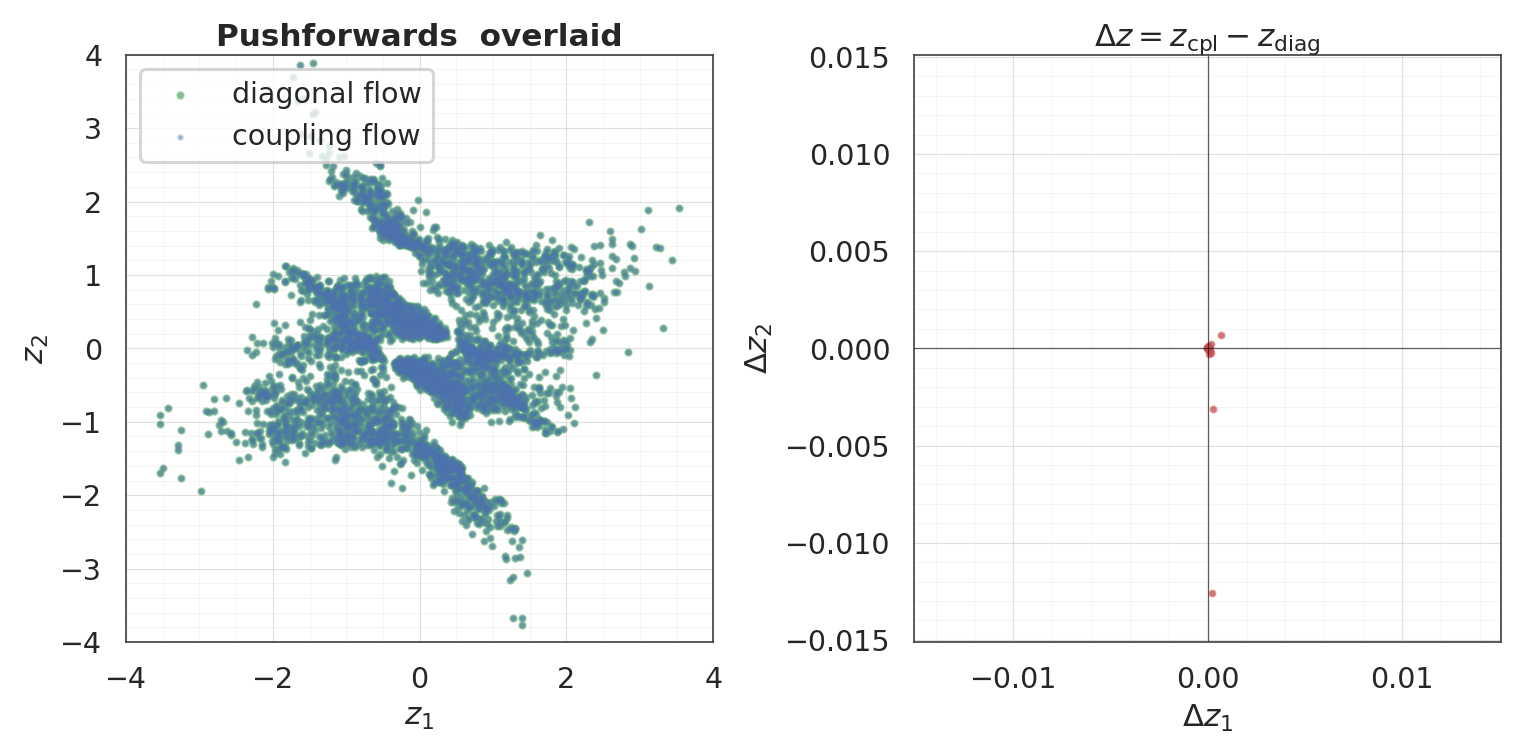

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

ax = axes[0]
ax.scatter(z_diag[:, 0], z_diag[:, 1], s=12, alpha=0.55,
           color=COLOR_DIAG, label="diagonal flow")
ax.scatter(z_cpl[:, 0], z_cpl[:, 1], s=5, alpha=0.35,
           color=COLOR_CPL, label="coupling flow")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title("Pushforwards  overlaid")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.legend(loc="upper left", frameon=True)
style_axes(ax, aspect="equal")

ax = axes[1]
delta = z_cpl - z_diag
lim = max(1e-5, np.max(np.abs(delta)) * 1.2)
ax.scatter(delta[:, 0], delta[:, 1], s=10, alpha=0.6, color=COLOR_DELTA)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel("$\\Delta z_1$")
ax.set_ylabel("$\\Delta z_2$")
ax.set_title("$\\Delta z = z_{\\mathrm{cpl}} - z_{\\mathrm{diag}}$")
style_axes(ax, aspect="equal")

plt.show()

## 5. Training breaks the equivalence

One gradient step of the coupling flow sets its final-Dense kernels $W$ to nonzero values. The conditioner stops being constant-in-$x_a$, and the layer becomes a genuinely conditional transform. From that point on, $f_\text{cpl}$ diverges from $f_\text{diag}$.

Train only the coupling flow (the diagonal flow stays frozen as the reference). Re-check the pointwise error after a handful of epochs.

In [5]:
flow_cpl.compile(optimizer=keras.optimizers.Adam(3e-3), loss=base_nll_loss)
hist = flow_cpl.fit(X, X, batch_size=512, epochs=20, verbose=0)

z_cpl_trained = ops.convert_to_numpy(flow_cpl(ops.convert_to_tensor(X)))
err_trained = np.linalg.norm(z_cpl_trained - z_diag, axis=-1)
lp_cpl_trained = ops.convert_to_numpy(flow_cpl.log_prob(ops.convert_to_tensor(X)))
lp_err_trained = np.abs(lp_cpl_trained - lp_diag)

print("after 20 epochs of coupling-flow training:")
print()
print("pushforward difference  ||z_cpl - z_diag||_2")
print(f"  median : {np.median(err_trained):.2e}")
print(f"  95th%  : {np.percentile(err_trained, 95):.2e}")
print(f"  max    : {err_trained.max():.2e}")
print()
print("log-prob difference     |log p_cpl(x) - log p_diag(x)|")
print(f"  median : {np.median(lp_err_trained):.2e}")
print(f"  95th%  : {np.percentile(lp_err_trained, 95):.2e}")
print(f"  max    : {lp_err_trained.max():.2e}")
print()
print(f"mean log-likelihood  diagonal (frozen) = {lp_diag.mean():+.3f} nats/sample")
print(f"mean log-likelihood  coupling (trained) = {lp_cpl_trained.mean():+.3f} nats/sample")

after 20 epochs of coupling-flow training:

pushforward difference  ||z_cpl - z_diag||_2
  median : 1.99e-01
  95th%  : 6.11e-01
  max    : 2.41e+00

log-prob difference     |log p_cpl(x) - log p_diag(x)|
  median : 8.34e-01
  95th%  : 2.11e+00
  max    : 7.66e+00

mean log-likelihood  diagonal (frozen) = -1.827 nats/sample
mean log-likelihood  coupling (trained) = -1.122 nats/sample


### Visualise the divergence

Same two panels, *after* training. Now the overlay shows two visibly different point clouds, and $\Delta z$ fills a non-trivial region of the plane — the conditioner has learnt cross-dim structure the diagonal flow cannot express.

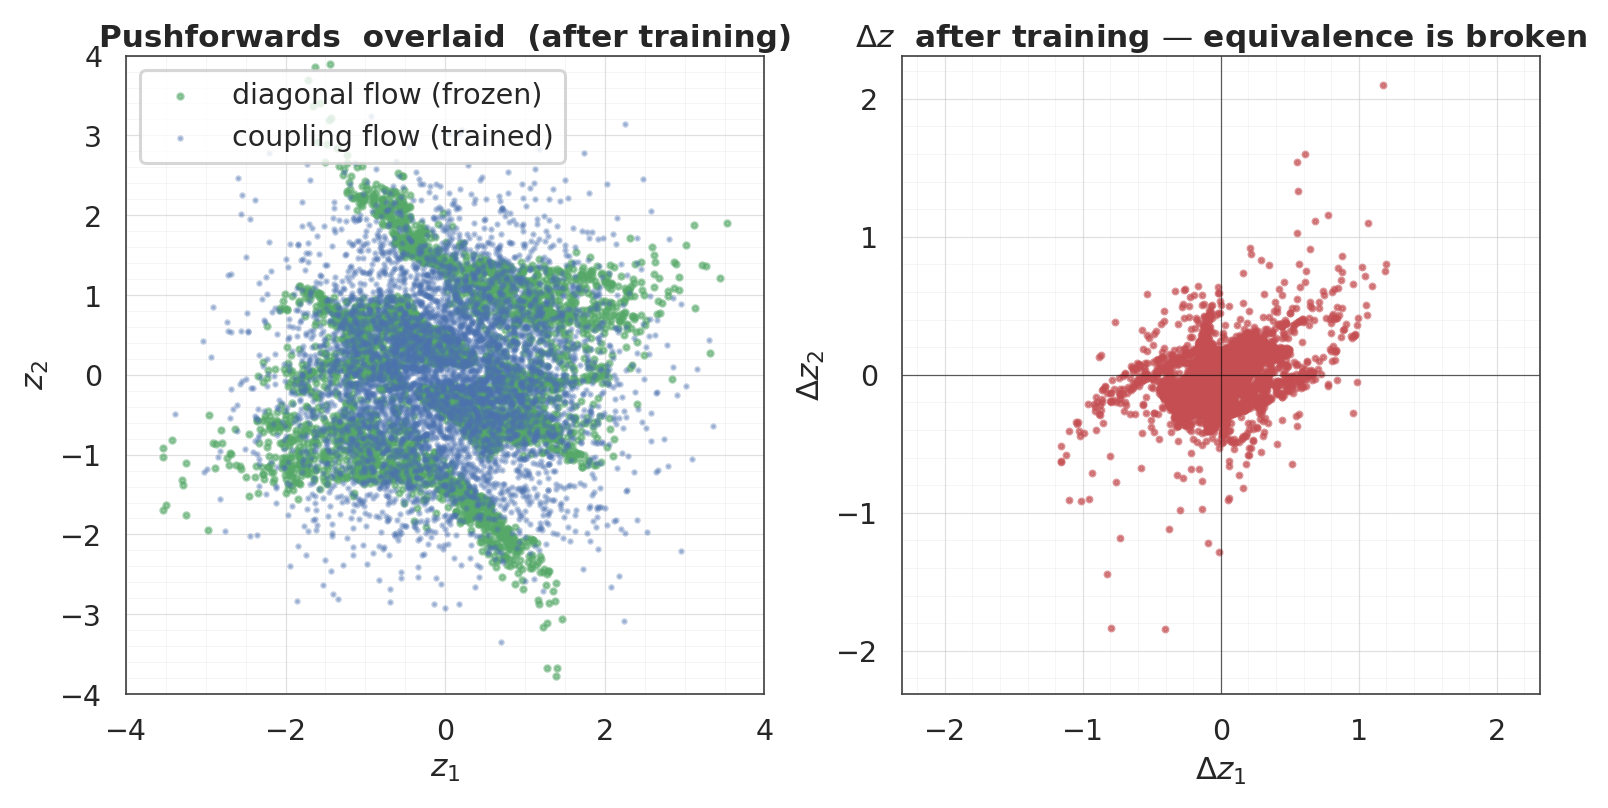

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

ax = axes[0]
ax.scatter(z_diag[:, 0], z_diag[:, 1], s=12, alpha=0.55,
           color=COLOR_DIAG, label="diagonal flow (frozen)")
ax.scatter(z_cpl_trained[:, 0], z_cpl_trained[:, 1], s=5, alpha=0.35,
           color=COLOR_CPL, label="coupling flow (trained)")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title("Pushforwards  overlaid  (after training)")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.legend(loc="upper left", frameon=True)
style_axes(ax, aspect="equal")

ax = axes[1]
delta_trained = z_cpl_trained - z_diag
lim = max(0.05, np.max(np.abs(delta_trained)) * 1.1)
ax.scatter(delta_trained[:, 0], delta_trained[:, 1], s=10, alpha=0.6, color=COLOR_DELTA)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel("$\\Delta z_1$")
ax.set_ylabel("$\\Delta z_2$")
ax.set_title("$\\Delta z$  after training — equivalence is broken")
style_axes(ax, aspect="equal")

plt.show()

### Error magnitudes side-by-side

One bar chart comparing the pointwise $L_2$ error and log-prob difference, before vs after training. Log scale on the y-axis because the two regimes differ by 6+ orders of magnitude.

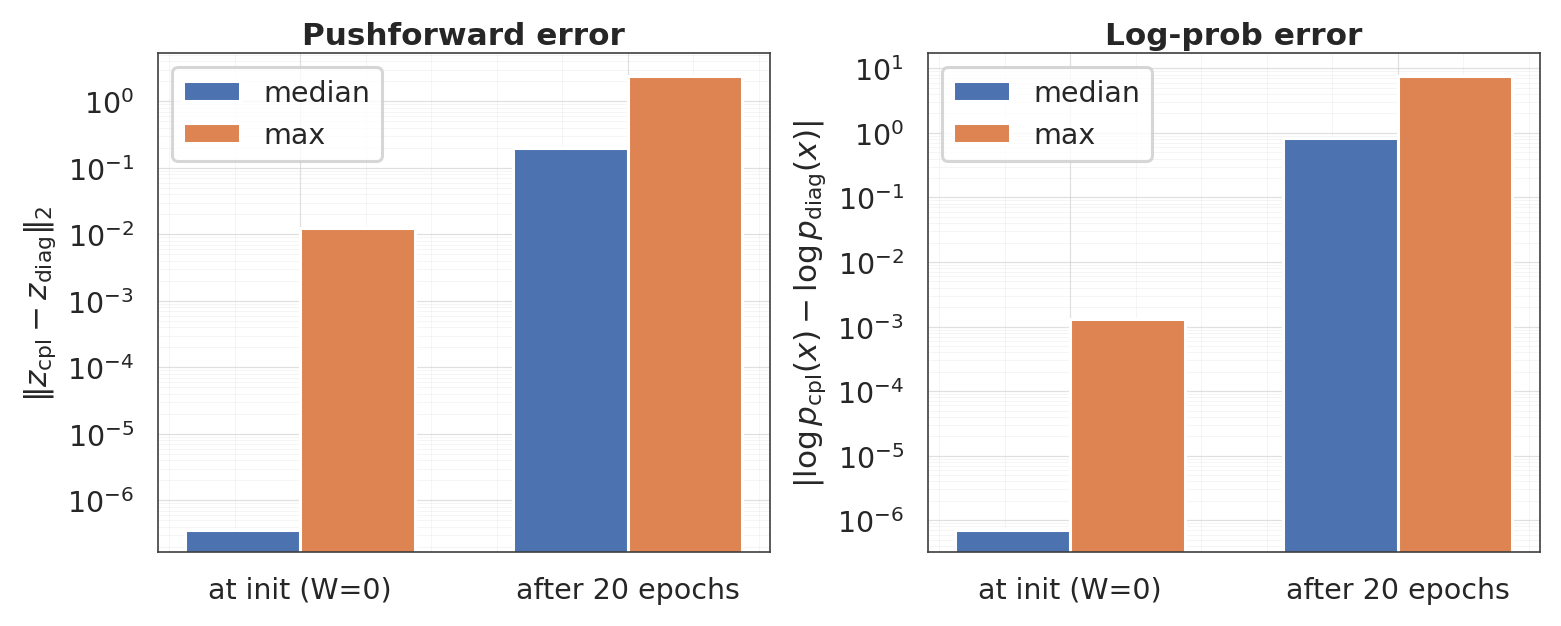

In [7]:
stats = {
    "at init (W=0)":   (err, lp_err),
    "after 20 epochs": (err_trained, lp_err_trained),
}
labels = list(stats.keys())
err_medians = [np.median(stats[k][0]) for k in labels]
err_maxs    = [stats[k][0].max()       for k in labels]
lp_medians  = [np.median(stats[k][1]) for k in labels]
lp_maxs     = [stats[k][1].max()       for k in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
width = 0.35
x = np.arange(len(labels))

ax = axes[0]
ax.bar(x - width/2, err_medians, width, label="median", color=palette[0])
ax.bar(x + width/2, err_maxs,    width, label="max",    color=palette[1])
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("$\\|z_\\mathrm{cpl} - z_\\mathrm{diag}\\|_2$")
ax.set_title("Pushforward error")
ax.legend(loc="upper left", frameon=True)
style_axes(ax)

ax = axes[1]
ax.bar(x - width/2, lp_medians, width, label="median", color=palette[0])
ax.bar(x + width/2, lp_maxs,    width, label="max",    color=palette[1])
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("$|\\log p_\\mathrm{cpl}(x) - \\log p_\\mathrm{diag}(x)|$")
ax.set_title("Log-prob error")
ax.legend(loc="upper left", frameon=True)
style_axes(ax)

plt.show()

## Takeaways

- At zero-kernel init the coupling flow is a **reparameterisation** of a diagonal Gaussianization flow, which itself is the parametric form of RBIG. Three different architectures, one function — empirically equal to float precision.
- The only freedom unused at init is the conditioner's final kernel $W$. Training lets that kernel grow, which is exactly what turns a diagonal Gaussianization into a genuinely conditional coupling flow.
- Practical implication: when using `make_coupling_flow` + `initialize_flow_from_ig`, you can think of the first forward pass as "here is RBIG" and of training as "now refine RBIG with cross-dim modulation". The warm-start doesn't constrain the eventual model — only the starting point.